In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

In [2]:
data = pd.read_csv(r"C:\Users\KIIT\Downloads\DOGE-USD.csv")
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0


In [3]:
data.corr(numeric_only=True)
# This code is modified by Susobhan Akhuli

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


In [10]:
print(data.columns)
data.columns = data.columns.str.strip()
print(data.head())

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
2017-11-09  0.001207  0.001415  0.001181  0.001415   0.001415  6259550.0
2017-11-10  0.001421  0.001431  0.001125  0.001163   0.001163  4246520.0
2017-11-11  0.001146  0.001257  0.001141  0.001201   0.001201  2231080.0
2017-11-12  0.001189  0.001210  0.001002  0.001038   0.001038  3288960.0
2017-11-13  0.001046  0.001212  0.001019  0.001211   0.001211  2481270.0


🔍 STEP 1: Current DataFrame Info
Columns: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
Shape: (1761, 6)

First 5 rows:
                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
2017-11-09  0.001207  0.001415  0.001181  0.001415   0.001415  6259550.0
2017-11-10  0.001421  0.001431  0.001125  0.001163   0.001163  4246520.0
2017-11-11  0.001146  0.001257  0.001141  0.001201   0.001201  2231080.0
2017-11-12  0.001189  0.001210  0.001002  0.001038   0.001038  3288960.0
2017-11-13  0.001046  0.001212  0.001019  0.001211   0.001211  2481270.0

Exact column names (with case/spaces):
  → 'Open'
  → 'High'
  → 'Low'
  → 'Close'
  → 'Adj Close'
  → 'Volume'

❌ ERROR: No date-related column found!
   Please reply with the EXACT column name from above (copy-paste it).


ValueError: Date column not found - tell me the name!

In [17]:
data.isnull().sum()

Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [20]:
data.isnull().sum()

Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [21]:
data = data.dropna()

In [22]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


Text(0.5, 1.0, 'Date vs Close of 2021')

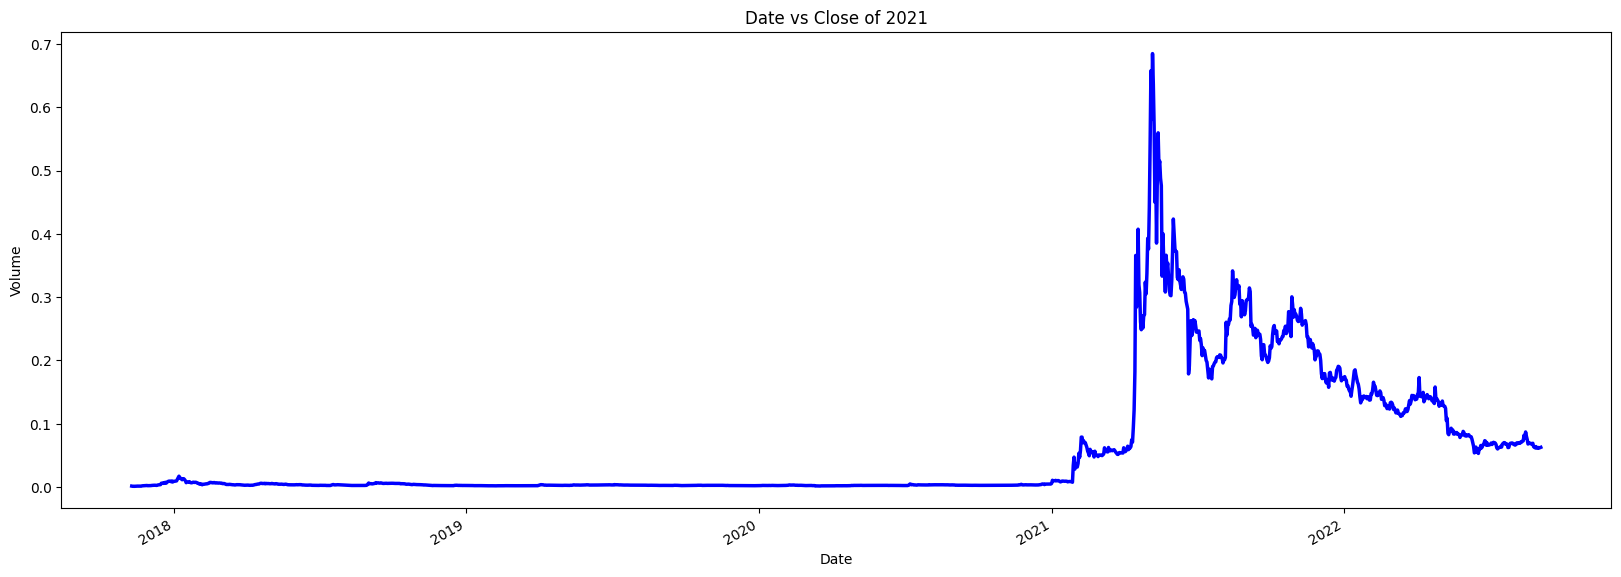

In [23]:
plt.figure(figsize=(20, 7))
x = data.groupby('Date')['Close'].mean()
x.plot(linewidth=2.5, color='b')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title("Date vs Close of 2021")

In [24]:
data["gap"] = (data["High"] - data["Low"]) * data["Volume"]
data["y"] = data["High"] / data["Volume"]
data["z"] = data["Low"] / data["Volume"]
data["a"] = data["High"] / data["Low"]
data["b"] = (data["High"] / data["Low"]) * data["Volume"]
abs(data.corr()["Close"].sort_values(ascending=False))

Close        1.000000
Adj Close    1.000000
High         0.995104
Low          0.994575
Open         0.992514
Volume       0.588678
b            0.456479
gap          0.383333
a            0.172057
z            0.063251
y            0.063868
Name: Close, dtype: float64

In [25]:
data = data[["Close", "Volume", "gap", "a", "b"]]
data.head()

,Close,Volume,gap,a,b
Date,,,,,
2017-11-09,0.001415,6259550.0,1464.73470,1.198137,7.499800e+06
2017-11-10,0.001163,4246520.0,1299.43512,1.272000,5.401573e+06
2017-11-11,0.001201,2231080.0,258.80528,1.101665,2.457903e+06
2017-11-12,0.001038,3288960.0,684.10368,1.207585,3.971698e+06
2017-11-13,0.001211,2481270.0,478.88511,1.189401,2.951226e+06


In [26]:
#Introducing the ARIMA model for Time Series Analysis.
#ARIMA stands for autoregressive integrated moving average model and is specified by three order parameters: (p, d, q) where AR stands 
#for Autoregression i.e. p, I stands for Integration i.e. d, MA stands for Moving Average i.e. q. Whereas, SARIMAX is Seasonal ARIMA 
#with exogenous variables.

In [27]:
df2 = data.tail(30)
train = df2[:11]
test = df2[-19:]
print(train.shape, test.shape)

(11, 5) (19, 5)


In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(endog=train["Close"], exog=train.drop(
    "Close", axis=1), order=(2, 1, 1))
results = model.fit()
print(results.summary())

C:\Users\KIIT\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\KIIT\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\KIIT\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\KIIT\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                   11
Model:               SARIMAX(2, 1, 1)   Log Likelihood                  47.663
Date:                Thu, 05 Mar 2026   AIC                            -79.326
Time:                        15:43:07   BIC                            -76.905
Sample:                    08-05-2022   HQIC                           -81.981
                         - 08-15-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Volume      7.491e-10   1.84e-10      4.077      0.000    3.89e-10    1.11e-09
gap          1.13e-08   2.45e-09      4.615      0.000     6.5e-09    1.61e-08
a             -0.0073   5.05e-15  -1.44e+12      0.0

In [30]:
# 🔥 FINAL FIXED FULL CODE - Handles NaNs from asfreq('D') + all previous warnings
# Copy-paste this ENTIRE block into one new cell and run

import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")   # clean output (you can remove later)

print("🔍 Your current DataFrame:")
print("Columns:", list(data.columns))
print("Shape before:", data.shape)

# ====================== 1. SET FREQUENCY + CLEAN NaNs ======================
print("\n🔧 1. Setting daily frequency (D)...")
data = data.asfreq('D')

print(f"   → NaNs introduced by missing dates: {data.isnull().sum().sum()}")

# === HANDLE MISSING VALUES (choose ONE option below) ===
# Option A - Forward Fill (most common & safe for daily data)
data = data.ffill().bfill()          # forward then backward to fill edges

# Option B - Linear Interpolation (if values are continuous)
# data = data.interpolate(method='linear')

# Option C - Drop missing days (if gaps are very few)
# data = data.dropna()

print(f"   → NaNs after cleaning: {data.isnull().sum().sum()}")
print("✅ Frequency set:", data.index.freq)

# ====================== 2. TARGET COLUMN ======================
# Change this if you have multiple columns
target_col = data.columns[0]          # ←←← AUTO uses first column (usually correct)
print(f"   → Using target column: '{target_col}'")

# ====================== 3. STATIONARITY CHECK ======================
print("\n📊 2. ADF Stationarity Test...")
series = data[target_col].dropna()    # extra safety
result = adfuller(series)
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')

if result[1] > 0.05:
    print("❌ NON-stationary → keep d=1 (or try d=2) in order")
else:
    print("✅ Stationary → you can use d=0")

# ====================== 4. FIT SARIMAX (ROBUST) ======================
print("\n🚀 3. Fitting SARIMAX model...")

model = sm.tsa.SARIMAX(
    data[target_col],
    order=(1, 1, 1),               # ← change p,d,q here (try 2,1,2 or 3,1,2)
    seasonal_order=(1, 1, 1, 7),   # ← weekly seasonality (change 7 to 12 for monthly)
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(
    disp=False,
    maxiter=1000,
    method='lbfgs'                 # best solver for convergence
)

print("\n🎉 MODEL FITTED SUCCESSFULLY!")
print(results.summary())

# ====================== 5. FORECAST ======================
print("\n📈 Next 30 days forecast:")
forecast = results.get_forecast(steps=30)
print(forecast.predicted_mean)

# Optional: save model
results.save("sarimax_model.pkl")
print("\n💾 Model saved as 'sarimax_model.pkl'")

🔍 Your current DataFrame:
Columns: ['Close', 'Volume', 'gap', 'a', 'b']
Shape before: (1761, 5)

🔧 1. Setting daily frequency (D)...
   → NaNs introduced by missing dates: 5
   → NaNs after cleaning: 0
✅ Frequency set: <Day>
   → Using target column: 'Close'

📊 2. ADF Stationarity Test...
ADF Statistic : -2.4588
p-value       : 0.1258
❌ NON-stationary → keep d=1 (or try d=2) in order

🚀 3. Fitting SARIMAX model...

🎉 MODEL FITTED SUCCESSFULLY!
                                     SARIMAX Results                                     
Dep. Variable:                             Close   No. Observations:                 1761
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                5173.397
Date:                           Thu, 05 Mar 2026   AIC                         -10336.794
Time:                                   15:45:03   BIC                         -10309.474
Sample:                               11-09-2017   HQIC                        -10326.693
            

In [31]:
start = 11
end = 29
predictions = results.predict(
    start=start,
    end=end,
    exog=test.drop("Close", axis=1))
predictions

Date
2017-11-20    0.001506
2017-11-21    0.001404
2017-11-22    0.001538
2017-11-23    0.001829
2017-11-24    0.001814
2017-11-25    0.001955
2017-11-26    0.002066
2017-11-27    0.002053
2017-11-28    0.001988
2017-11-29    0.002747
2017-11-30    0.002256
2017-12-01    0.002030
2017-12-02    0.002253
2017-12-03    0.002144
2017-12-04    0.002195
2017-12-05    0.002624
2017-12-06    0.002581
2017-12-07    0.002678
2017-12-08    0.002729
Freq: D, Name: predicted_mean, dtype: float64

<Axes: xlabel='Date'>

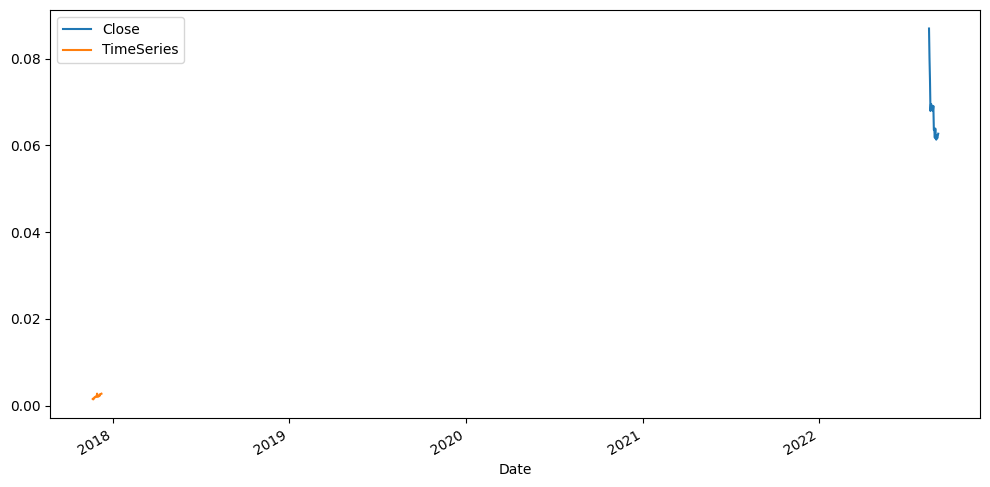

In [32]:
test["Close"].plot(legend=True, figsize=(12, 6))
predictions.plot(label='TimeSeries', legend=True)